<a href="https://colab.research.google.com/github/mbananth/fantastic-sniffle/blob/main/lab0_qgss26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install qiskit[visualization] qiskit-ibm-runtime qiskit-aer pylatexenc

In [6]:
from google.colab import userdata
from qiskit_ibm_runtime import QiskitRuntimeService

# Fetch the token securely from Colab Secrets
ibm_token = userdata.get('QISKIT_IBM_TOKEN')

# Save your credentials to the Colab environment
QiskitRuntimeService.save_account(
    channel="ibm_cloud",
    token=ibm_token,
    overwrite=True,
    set_as_default=True
)

# Initialize the service
service = QiskitRuntimeService()
print("Successfully connected to IBM Quantum!")

qiskit_runtime_service.__init__:WARNING:2026-07-15 11:51:40,206: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: QGSS26. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Successfully connected to IBM Quantum!


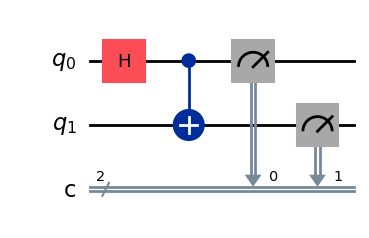

In [7]:
from qiskit import QuantumCircuit

# Create a circuit with 2 qubits and 2 classical bits
qc = QuantumCircuit(2, 2)

# Apply a Hadamard gate to qubit 0 to put it in superposition
qc.h(0)

# Apply a CNOT gate to entangle qubit 0 and qubit 1
qc.cx(0, 1)

# Measure both qubits into the classical bits
qc.measure([0, 1], [0, 1])

# Draw the circuit visually
qc.draw('mpl')

In [ ]:
from qiskit_ibm_runtime import SamplerV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# 1. Select a backend (You can request the least busy physical device)
# To run on a cloud simulator instead, use: backend = service.backend("ibmq_qasm_simulator")
backend = service.least_busy(operational=True, simulator=False)
print(f"Running on real quantum hardware: {backend.name}")

# 2. Transpile the circuit to match the hardware's target topology
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(qc)

# 3. Initialize the Sampler and run the job
sampler = SamplerV2(backend)
job = sampler.run([isa_circuit])

print(f"Job ID: {job.job_id()}")
print("Your job has been submitted! You can track its progress on your IBM Quantum Dashboard account.")

In [8]:
import sys

recommended = (3, 10)
current = sys.version_info[:2]

if current < recommended:
    print(f"You are using Python {current[0]}.{current[1]}. Python {recommended[0]}.{recommended[1]} or later is recommended.")
else:
    print(f"Python {current[0]}.{current[1]} — looks good!")

Python 3.12 — looks good!


In [9]:
# Install required packages.
# Uncomment the lines below the first time you run this notebook to install dependencies,
# then re-comment them on subsequent runs.


%pip install --upgrade 'qiskit[visualization]>=2.5.0' qiskit-aer qiskit-ibm-runtime matplotlib
%pip install --upgrade qc-grader

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 76.1 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 42.7 MB/s eta 0:00:00


In [26]:
import os
import platform
import shutil
import subprocess
import sys

import qc_grader
import qiskit

from qc_grader.challenges.qgss_2026 import check_progress
from qc_grader.challenges.qgss_2026.lab0 import (
    grade_lab0_ex1,
    grade_lab0_ex2,
    grade_lab0_ex3,
    grade_lab0_ex4,
)


from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import array_to_latex, plot_histogram, plot_state_qsphere
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

import matplotlib.pyplot as plt

print(f"Qiskit version: {qiskit.__version__}")
print(f"Grader version: {qc_grader.__version__}")

Qiskit version: 2.5.0
Grader version: 2026.7.2


In [2]:


# Paste your IBM Cloud credentials here. You only need to do this once per environment.
# After it works, you can comment these lines out so the credentials do not stay in the file.

#token = "<YOUR_API_KEY>"
#instance = "<YOUR_CRN>"  # looks like "crn:v1:bluemix:public:quantum-computing:..."

#QiskitRuntimeService.save_account(
#    token=token,
#    instance=instance,
#    overwrite=True,
#    set_as_default=True,
#)

# Verify
service = QiskitRuntimeService()
backends = service.backends()
print(f"Account OK. {len(backends)} backend(s) available:")
for b in backends[:5]:
    print(f"  {b.name} ({b.num_qubits} qubits)")



qiskit_runtime_service.__init__:WARNING:2026-07-15 12:23:04,920: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: QGSS26. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-07-15 12:23:04,922: Loading instance: QGSS26, plan: open


Account OK. 3 backend(s) available:
  ibm_kingston (156 qubits)
  ibm_marrakesh (156 qubits)
  ibm_fez (156 qubits)


In [3]:
grade_lab0_ex1()

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-15 12:23:53,349: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: QGSS26. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


🎉 Your IBM Quantum account is properly configured!
You have successfully connected to the grading server.
You're all set to continue with the rest of the lab.
You scored 1 on this exercise.


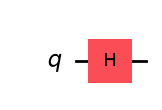

In [21]:
qc = QuantumCircuit(1)

# TODO: Add a Hadamard gate on qubit 0
qc.h(0)

qc.draw("mpl")

In [17]:
# TODO: Define the observable as the single-qubit Z operator
observable = SparsePauliOp("Z")

print(f"Observable: {observable}")

Observable: SparsePauliOp(['Z'],
              coeffs=[1.+0.j])


In [19]:
check_progress("lab0")

Fetching your progress. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-15 12:40:12,957: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: QGSS26. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


📊 Your progress

Lab "lab0" — 1/4 passed, score 1.0
  ✅ ex1 — score 1.0
  ⬜ ex2 — score 0.0
  ⬜ ex3 — score 0.0
  ⬜ ex4 — score 0.0


In [18]:
backend = AerSimulator()
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)

# Sampler requires measurements in the circuit
qc_meas = qc.copy()
qc_meas.measure_all()
isa_qc_meas = pm.run(qc_meas)

# Estimator takes the circuit without measurements and evaluates the observable separately
isa_qc = pm.run(qc)

# Apply the same layout to the observable so qubit indices match the transpiled circuit
isa_observable = observable.apply_layout(isa_qc.layout)

print("Transpiled circuit and observable ready.")

Transpiled circuit and observable ready.


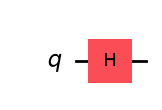

In [28]:
qc = QuantumCircuit(1)

# TODO: Add a Hadamard gate on qubit 0
qc.h(0)

qc.draw("mpl")

In [23]:
# TODO: Define the observable as the single-qubit Z operator
observable = SparsePauliOp(Z"

print(f"Observable: {observable}")

Observable: None


In [24]:
import numpy as np
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp

In [29]:
# TODO: Define the observable as the single-qubit Z operator
observable = SparsePauliOp('Z')

print(f"Observable: {observable}")

Observable: SparsePauliOp(['Z'],
              coeffs=[1.+0.j])


In [30]:
backend = AerSimulator()
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)

# Sampler requires measurements in the circuit
qc_meas = qc.copy()
qc_meas.measure_all()
isa_qc_meas = pm.run(qc_meas)

# Estimator takes the circuit without measurements and evaluates the observable separately
isa_qc = pm.run(qc)

# Apply the same layout to the observable so qubit indices match the transpiled circuit
isa_observable = observable.apply_layout(isa_qc.layout)

print("Transpiled circuit and observable ready.")

Transpiled circuit and observable ready.


In [31]:
sampler = Sampler(mode=backend)
sampler_result = sampler.run([isa_qc_meas], shots=1000).result()
counts = sampler_result[0].data.meas.get_counts()

print("Sampler counts:", counts)

Sampler counts: {'0': 491, '1': 509}


In [32]:
grade_lab0_ex2(counts)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-15 14:42:55,953: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: QGSS26. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Congratulations! 🎉 Your answer is correct. 491:509 — looks like 50/50 superposition from the Hadamard gate.
You scored 1 on this exercise.


In [33]:
# Run Estimator — circuit WITHOUT measurements + observable
estimator = Estimator(mode=backend)
estimator_result = estimator.run([(isa_qc, isa_observable)]).result()
exp_val = estimator_result[0].data.evs

print(f"⟨Z⟩ = {exp_val:.4f}")

⟨Z⟩ = -0.0229


In [34]:
grade_lab0_ex3(exp_val)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-15 14:43:42,042: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: QGSS26. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Congratulations! 🎉 Your answer is correct. ⟨Z⟩ = -0.0229 ≈ 0
You scored 1 on this exercise.


Sampler counts: {'0': 491, '1': 509}


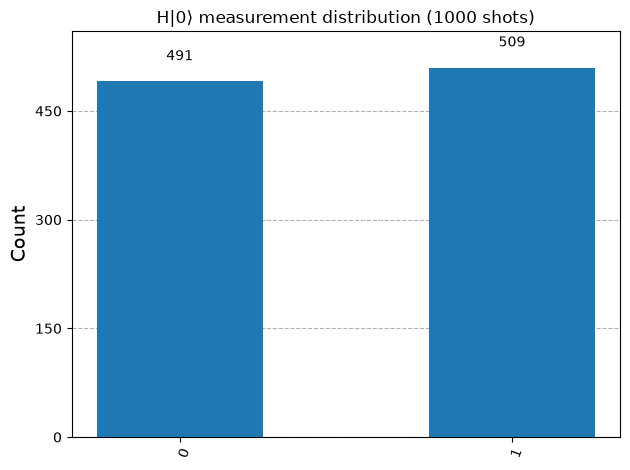


Estimator ⟨Z⟩ = -0.0229 ± 0.0156


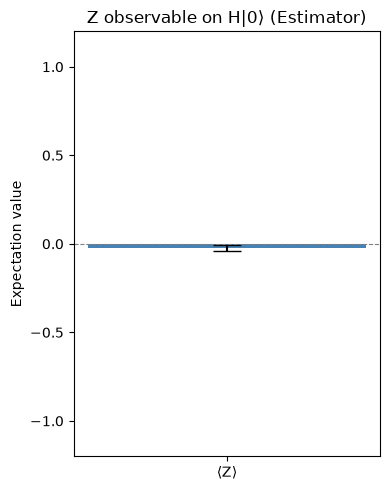

In [99]:
# Sampler results
print(f"Sampler counts: {counts}")
display(plot_histogram(counts, title="H|0⟩ measurement distribution (1000 shots)"))

# Estimator results
ev = estimator_result[0].data.evs.item()
std = estimator_result[0].data.stds.item()
print(f"\nEstimator ⟨Z⟩ = {ev:.4f} ± {std:.4f}")

fig, ax = plt.subplots(figsize=(4, 5))
ax.bar(["⟨Z⟩"], [ev], yerr=[std], capsize=10, color="steelblue", width=0.4)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_ylim(-1.2, 1.2)
ax.set_ylabel("Expectation value")
ax.set_title("Z observable on H|0⟩ (Estimator)")
plt.tight_layout()
plt.show()

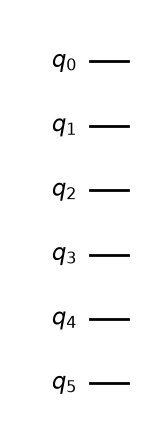

In [100]:
# Step 1: Create a 6-qubit circuit
special_qc = QuantumCircuit(6)
special_qc.draw("mpl")

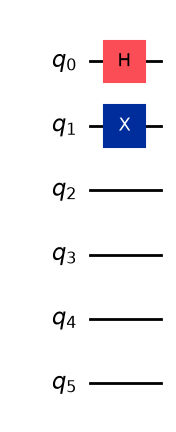

In [101]:
# Step 2: H on qubit 0, X on qubit 1
# TODO: Apply H to qubit 0
special_qc.h(0)
# TODO: Apply X to qubit 1
special_qc.x(1)

special_qc.draw('mpl')

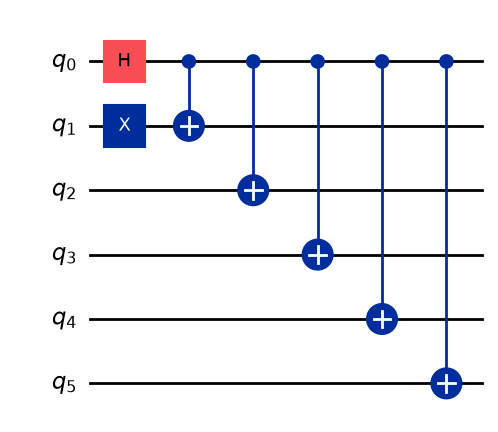

In [102]:

# Step 3: CNOT chain — entangle all qubits with qubit 0
# TODO: Loop over qubits 1 through 5 and apply CNOT with qubit 0 as control

for i in range(1, 6):
  special_qc.cx(0, i)
special_qc.draw('mpl')

In [103]:
sv = Statevector(special_qc)
array_to_latex(sv, max_size=64)

<IPython.core.display.Latex object>

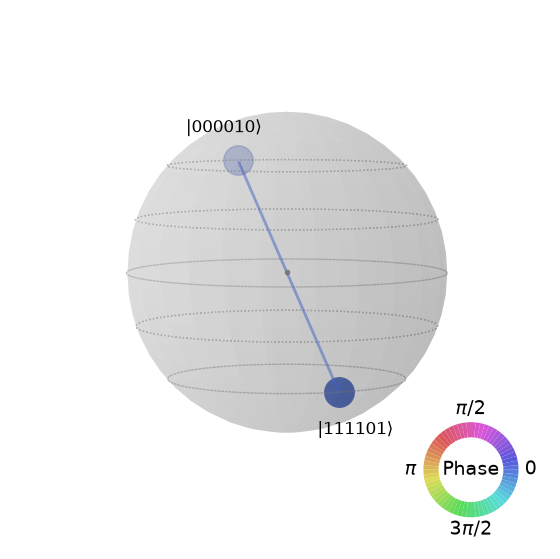

In [104]:
# The QSphere
plot_state_qsphere(sv)

In [105]:
grade_lab0_ex4(sv)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-15 15:43:37,238: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: QGSS26. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Congratulations! 🎉 Your answer is correct. Fidelity: 1.000000
You just created the Qiskit logo!

Looking forward to the QGSS main event starting in a week? Take this course:
https://quantum.cloud.ibm.com/learning/en/courses/use-a-qc-today
You scored 1 on this exercise.


In [106]:
check_progress("lab0")

Fetching your progress. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-15 15:44:09,885: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: QGSS26. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


📊 Your progress

Lab "lab0" — 4/4 passed, score 4.0
  ✅ ex1 — score 1.0
  ✅ ex2 — score 1.0
  ✅ ex3 — score 1.0
  ✅ ex4 — score 1.0


In [107]:
import sys
import os
import platform
import shutil
import subprocess

from qiskit.quantum_info import Statevector
from qiskit.visualization import array_to_latex, plot_state_qsphere

# Setup for macOS / Linux / Colab / qBraid.
# On Windows, see the note in 3.1 and use qBraid or Google Colab.

if platform.system() == "Windows":
    print("Windows: run this chapter on qBraid or Google Colab.")
else:
    IS_COLAB = "google.colab" in sys.modules

    # Colab does not have a compiler by default.
    if IS_COLAB and shutil.which("gcc") is None:
        subprocess.run(["apt-get", "-qq", "install", "-y", "build-essential"], check=True)

    # setuptools builds the C file into a Python module.
    try:
        import setuptools  # noqa: F401
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "setuptools"], check=True)

    cc = shutil.which("gcc") or shutil.which("clang")
    if cc is None:
        print("No C compiler found. On macOS run: xcode-select --install")
    else:
        print("C compiler:", cc)
        print("Setup done. Continue to 3.2.")

C compiler: /usr/bin/gcc
Setup done. Continue to 3.2.


In [ ]:
%%writefile qgss_circuit.c

#include <Python.h>
#include <qiskit.h>
#include <stdint.h>

static PyObject *build_special_circuit(PyObject *self, PyObject *args) {
    QkCircuit *qc = qk_circuit_new(6, 0);

    // TODO 1: Apply H to qubit 0.
    //   Use qk_circuit_gate with QkGate_H. See the C API reference.

    // TODO 2: Apply X to qubit 1.
    //   Use qk_circuit_gate with QkGate_X.

    // TODO 3: Add a CNOT chain. Control is qubit 0, targets are 1 to 5.
    //   For each target, call qk_circuit_gate with QkGate_CX and a {control, target} array.
    //   A for loop works here.

    return qk_circuit_to_python_full(qc);
}

static PyMethodDef methods[] = {
    {"build_special_circuit", build_special_circuit, METH_NOARGS, "Build the special circuit."},
    {NULL, NULL, 0, NULL},
};
static struct PyModuleDef moduledef = {
    .m_base = PyModuleDef_HEAD_INIT,
    .m_name = "qgss_circuit",
    .m_methods = methods,
};
PyMODINIT_FUNC PyInit_qgss_circuit(void) {
    if (qk_import() < 0) {
        return NULL;
    }
    return PyModuleDef_Init(&moduledef);